# 02. Species Distribution Modeling and Host-Plant Risk Lookup for Fruit Flies

This notebook builds two complementary components that together support pest mitigation planning for farmers.

1. **Climate-based Species Distribution Models (SDM)**: predict which regions are climatically suitable for each fruit fly species to survive, including regions with little or no direct observation record (for example East Africa), using WorldClim bioclimatic variables, elevation, and soil covariates.
2. **A host-plant association lookup**: built directly from observed interaction records, listing which crops or plants each species is documented to use as a host.

These two are deliberately kept separate rather than combined into a single spatial model. The host-plant records in this dataset are recorded at the same coordinates as the fly sightings themselves, so they cannot serve as independent evidence of where a host plant exists in the absence of the fly. Instead, the practical use of this notebook's output is: given a region that is climatically suitable for a species, and a known host-plant association list for that species, a farmer growing that host plant in that region can be flagged as being at elevated risk. This supports targeted monitoring rather than blanket treatment.

Input:
1. data/clean_data.csv (produced by notebook 01) and the environmental raster layers in Environmental_Layers, (WorldClim bio_1 to bio_19, elevation, soil clay, soil pH).

## Environment

Developed and run in a conda environment with the packages in `requirements.txt` installed. See `notebooks/01_eda.ipynb` for setup instructions.

# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# Load cleaned data

In [2]:
df = pd.read_csv('../data/clean_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (9199, 30)


,id,uuid,observed_on,obs_year,obs_month,quality_grade,license,latitude,longitude,positional_accuracy,coordinates_obscured,place_country_name,place_state_name,place_admin1_name,species_guess,scientific_name,common_name,taxon_genus_name,taxon_species_name,host_plant,Data_Category,num_identification_agreements,num_identification_disagreements,url,image_url,taxon_resolution,has_host_plant,is_research_grade,has_coords,coord_reliable
0,229489,6bb20884-a1a8-4a32-a5c8-2cbed47d5ad6,2013-04-05,2013,4,needs_id,CC-BY-NC,24.432020,92.330689,31626.0,False,India,Assam,Assam,Bactrocera,Bactrocera,NaN,Bactrocera,NaN,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/229489,https://inaturalist-open-data.s3.amazonaws.com...,genus_or_higher,False,False,True,False
1,663857,3fca9700-5ad3-4232-93d3-04e460a1f13b,2011-10-14,2011,10,research,NaN,38.195269,13.335471,16.0,False,Italy,Sicily,Sicily,olive fruit fly,Bactrocera oleae,olive fruit fly,Bactrocera,Bactrocera oleae,Olea europaea,Interaction Study,2,0,http://www.inaturalist.org/observations/663857,https://static.inaturalist.org/photos/836423/m...,species,True,True,True,True
2,718148,997499b2-e0c4-4ce4-a15c-ff813133a315,2014-06-04,2014,6,research,CC-BY-NC-SA,1.348855,103.762573,NaN,False,Singapore,West,West,Bactrocera dorsalis,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/718148,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True
3,783490,446949ef-1baa-4e13-98f9-f0b44039a3ee,2014-07-06,2014,7,research,CC-BY-NC-ND,22.430309,114.086419,61.0,False,Hong Kong,Yuen Long,Yuen Long,æ±æ–¹æžœå¯¦è …,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,1,0,http://www.inaturalist.org/observations/783490,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True
4,791094,068abc8d-e1f1-447b-929d-35c63506c014,2014-07-12,2014,7,research,CC-BY-NC-ND,1.317138,103.815919,217.0,False,Singapore,Central,Central,Bactrocera dorsalis,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/791094,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True


## Part 1: Host-Pest interaction Analysis

Using only the records with a known host plant (`Data_Category == 'Interaction Study'`), look at which fly species associate with which host plants.

In [44]:
import os, json
os.makedirs('../outputs/models', exist_ok=True)
with open('../outputs/models/host_plant_lookup.json', 'w') as f:
    json.dump(host_plant_lookup, f, indent=2)
print('Saved to:', os.path.abspath('../outputs/models/host_plant_lookup.json'))

Saved to: c:\Users\skimanzi\Desktop\ENEZA_SIMON-PROJECT\outputs\models\host_plant_lookup.json


In [3]:
interactions = df[df['Data_Category'] == 'Interaction Study'].copy()
print('Interaction-study records:', len(interactions))
print('Unique species:', interactions['scientific_name'].nunique())
print('Unique host plants:', interactions['host_plant'].nunique())

Interaction-study records: 1673
Unique species: 32
Unique host plants: 12


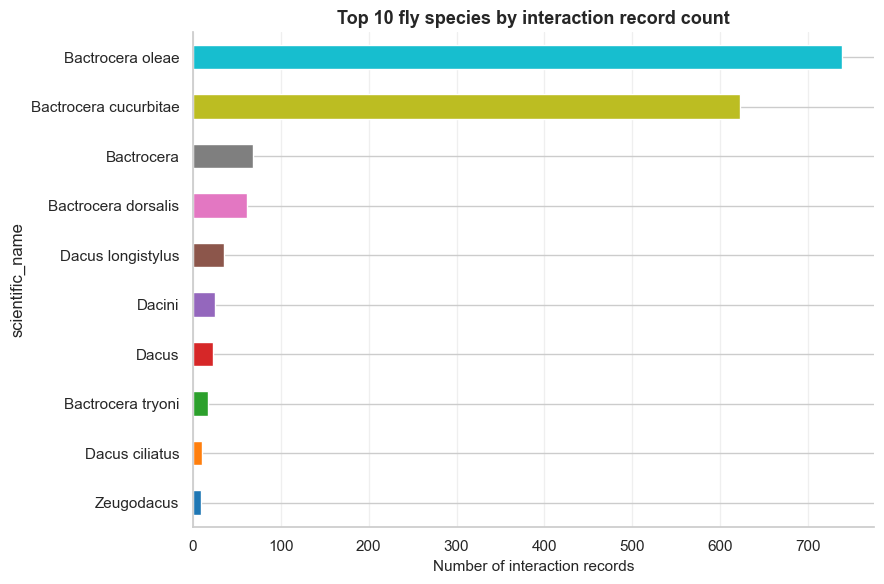

In [4]:
top_species = interactions['scientific_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_species)))
top_species.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of interaction records', fontsize=11)
ax.set_title('Top 10 fly species by interaction record count', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/top_species_interactions.png', dpi=150)
plt.show()

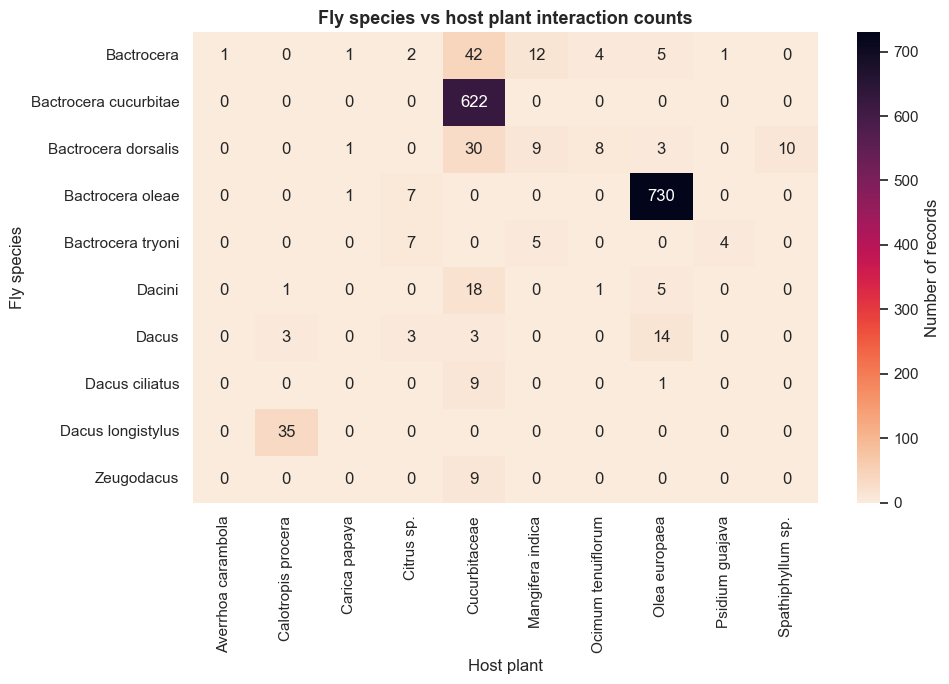

In [5]:
top_hosts = interactions['host_plant'].value_counts().head(10).index
top_sp = top_species.index

matrix = pd.crosstab(
    interactions[interactions['scientific_name'].isin(top_sp)]['scientific_name'],
    interactions[interactions['host_plant'].isin(top_hosts)]['host_plant']
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt='d', cmap='rocket_r', ax=ax, cbar_kws={'label': 'Number of records'})
ax.set_title('Fly species vs host plant interaction counts', fontsize=13, fontweight='bold')
ax.set_xlabel('Host plant')
ax.set_ylabel('Fly species')
plt.tight_layout()
plt.savefig('../outputs/figures/species_host_heatmap.png', dpi=150)
plt.show()

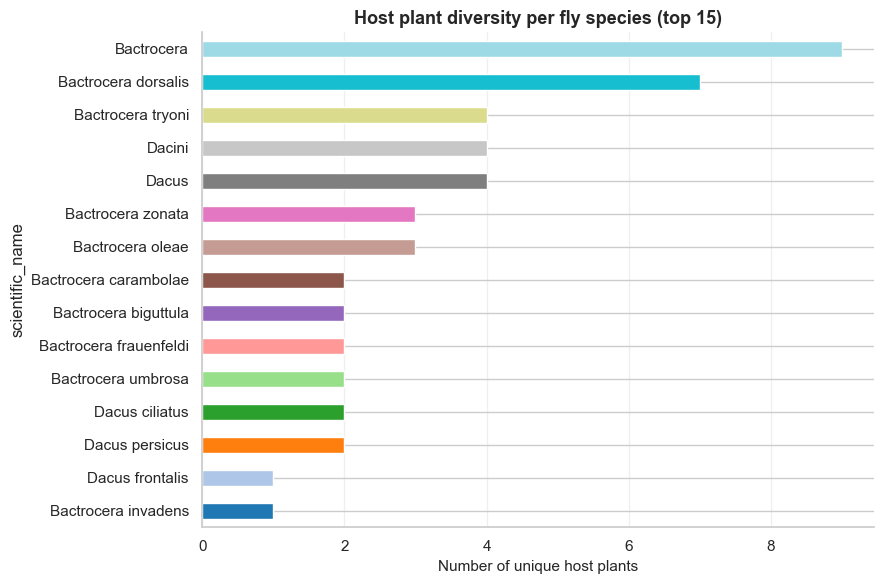

In [6]:
host_diversity = interactions.groupby('scientific_name')['host_plant'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
n = min(15, len(host_diversity))
colors = plt.cm.tab20(np.linspace(0, 1, n))
host_diversity.head(n).sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of unique host plants', fontsize=11)
ax.set_title('Host plant diversity per fly species (top 15)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/host_diversity_per_species.png', dpi=150)
plt.show()

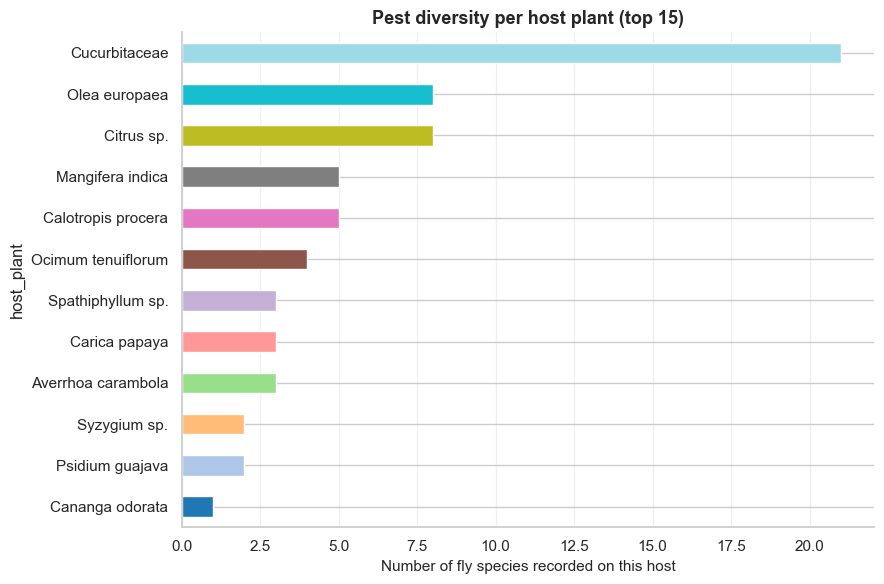

In [7]:
pest_diversity = interactions.groupby('host_plant')['scientific_name'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
n = min(15, len(pest_diversity))
colors = plt.cm.tab20(np.linspace(0, 1, n))
pest_diversity.head(n).sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of fly species recorded on this host', fontsize=11)
ax.set_title('Pest diversity per host plant (top 15)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/pest_diversity_per_host.png', dpi=150)
plt.show()

### Build the host-plant lookup table

This dictionary maps each fly species to its documented list of host plants. It is reused in Part 5 to turn a climate suitability prediction into an actionable, farmer-facing risk statement.

In [8]:
host_plant_lookup = (
    interactions.groupby('scientific_name')['host_plant']
    .apply(lambda x: sorted(x.unique()))
    .to_dict()
)

for sp, hosts in list(host_plant_lookup.items())[:5]:
    print(f'{sp}: {hosts}')

Bactrocera: ['Averrhoa carambola', 'Carica papaya', 'Citrus sp.', 'Cucurbitaceae', 'Mangifera indica', 'Ocimum tenuiflorum', 'Olea europaea', 'Psidium guajava', 'Syzygium sp.']
Bactrocera albistrigata: ['Citrus sp.']
Bactrocera biguttula: ['Citrus sp.', 'Olea europaea']
Bactrocera cacuminata: ['Citrus sp.']
Bactrocera carambolae: ['Averrhoa carambola', 'Spathiphyllum sp.']


## Part 2: Extract Environmental Covariates

For every occurrence with a reliable coordinate, sample the value of each environmental layer (19 WorldClim bioclimatic variables, elevation, soil clay content, soil pH) at that exact location.


In [9]:
ENV_DIR = 'C:/Users/skimanzi/Desktop/Dacini_SMD_project/Environmental_Layers'

env_files = {
    'bio_1': 'wc2.1_10m_bio_1.tif', 'bio_2': 'wc2.1_10m_bio_2.tif',
    'bio_3': 'wc2.1_10m_bio_3.tif', 'bio_4': 'wc2.1_10m_bio_4.tif',
    'bio_5': 'wc2.1_10m_bio_5.tif', 'bio_6': 'wc2.1_10m_bio_6.tif',
    'bio_7': 'wc2.1_10m_bio_7.tif', 'bio_8': 'wc2.1_10m_bio_8.tif',
    'bio_9': 'wc2.1_10m_bio_9.tif', 'bio_10': 'wc2.1_10m_bio_10.tif',
    'bio_11': 'wc2.1_10m_bio_11.tif', 'bio_12': 'wc2.1_10m_bio_12.tif',
    'bio_13': 'wc2.1_10m_bio_13.tif', 'bio_14': 'wc2.1_10m_bio_14.tif',
    'bio_15': 'wc2.1_10m_bio_15.tif', 'bio_16': 'wc2.1_10m_bio_16.tif',
    'bio_17': 'wc2.1_10m_bio_17.tif', 'bio_18': 'wc2.1_10m_bio_18.tif',
    'bio_19': 'wc2.1_10m_bio_19.tif',
    'elevation': 'wc2.1_10m_elev.tif',
    'clay': 'clay_0-5cm_mean_30s.tif',
    'ph': 'phh2o_0-5cm_mean_30s.tif',
}
env_files = {k: os.path.join(ENV_DIR, v) for k, v in env_files.items()}
covariate_cols = list(env_files.keys())

missing = [p for p in env_files.values() if not os.path.exists(p)]
print(f'{len(env_files)} layers registered, {len(missing)} missing')
if missing:
    print('Missing files:', missing)

22 layers registered, 0 missing


In [10]:
def _nearest_valid_pixel(band, row, col, max_radius_px):
    """Search outward from (row, col) for the nearest non-NaN pixel in a raster band."""
    for radius in range(0, max_radius_px + 1):
        r0, r1 = max(0, row - radius), min(band.shape[0], row + radius + 1)
        c0, c1 = max(0, col - radius), min(band.shape[1], col + radius + 1)
        window = band[r0:r1, c0:c1]
        if np.any(~np.isnan(window)):
            valid_idx = np.argwhere(~np.isnan(window))
            center = np.array([row - r0, col - c0])
            dists = np.linalg.norm(valid_idx - center, axis=1)
            best = valid_idx[np.argmin(dists)]
            return float(window[best[0], best[1]]), radius
    return np.nan, -1


def extract_covariates(points_df, lat_col='latitude', lon_col='longitude', fill_gaps=False, max_radius_px=15):
    """
    Sample every environmental layer at each (lat, lon) point.

    fill_gaps=False (default): used for bulk extraction over thousands of occurrence
    points (Part 2). Missing pixels are left as NaN and dropped downstream.

    fill_gaps=True: used for single-point farmer queries (Part 5). If the exact pixel
    has no data, the nearest valid pixel within max_radius_px is used instead of
    failing outright.
    """
    coords = list(zip(points_df[lon_col], points_df[lat_col]))
    result = points_df.copy()

    for name, path in env_files.items():
        with rasterio.open(path) as src:
            values = [v[0] for v in src.sample(coords)]
            values = [np.nan if (isinstance(v, float) and np.isnan(v)) else v for v in values]

            if fill_gaps and any(np.isnan(v) for v in values):
                band = src.read(1)
                for i, (lon, lat) in enumerate(coords):
                    if np.isnan(values[i]):
                        row, col = src.index(lon, lat)
                        filled, _ = _nearest_valid_pixel(band, row, col, max_radius_px)
                        values[i] = filled

            result[name] = values

    return result

In [11]:
geo_points = df[df['coord_reliable']].copy()
print('Points to extract covariates for:', len(geo_points))

covariates = extract_covariates(geo_points)
covariates[['scientific_name', 'latitude', 'longitude'] + covariate_cols].head()

Points to extract covariates for: 8339


,scientific_name,latitude,longitude,bio_1,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,bio_19,elevation,clay,ph
1,Bactrocera oleae,38.195269,13.335471,17.525000,6.300000,30.594902,538.091675,28.991667,8.400000,20.591667,15.859722,24.152779,24.525000,11.605556,479.0,70.0,3.0,58.101982,204.0,25.0,61.0,148.0,226,6.0,NaN
2,Bactrocera dorsalis,1.348855,103.762573,26.654299,6.862859,85.067688,43.173588,30.818390,22.750862,8.067528,26.330843,26.946838,27.133286,26.057423,2304.0,297.0,148.0,22.294577,745.0,455.0,533.0,744.0,26,22.0,5.2
3,Bactrocera dorsalis,22.430309,114.086419,22.117931,6.060862,30.716740,510.826660,30.934551,11.203090,19.731461,27.675749,16.988718,27.675749,15.367650,2033.0,365.0,25.0,77.972969,1027.0,90.0,1027.0,101.0,142,8.0,NaN
4,Bactrocera dorsalis,1.317138,103.815919,26.912443,7.008784,85.571693,42.593422,31.095270,22.904730,8.190540,26.317455,27.216892,27.374662,26.317455,2359.0,289.0,157.0,19.926325,760.0,492.0,541.0,760.0,16,23.0,NaN
5,Zeugodacus tau,23.499548,87.304627,26.340918,11.375667,42.699047,454.012024,38.320000,11.678500,26.641499,28.627834,20.248125,31.222500,20.056458,1228.0,273.0,4.0,104.792183,768.0,27.0,300.0,34.0,84,4.0,6.1


In [12]:
# Ph Sanity check: SoilGrids pH is sometimes stored as pH x 10
print('pH range:', covariates['ph'].min(), 'to', covariates['ph'].max())
if covariates['ph'].max() > 14:
    covariates['ph'] = covariates['ph'] / 10
    print('Rescaled pH, new range:', covariates['ph'].min(), 'to', covariates['ph'].max())

pH range: 4.599999904632568 to 9.300000190734863


In [13]:
# Drop rows where any covariate could not be sampled (point fell outside a raster's extent)
before = len(covariates)
covariates = covariates.dropna(subset=covariate_cols)
print(f'Dropped {before - len(covariates)} points with missing covariate values')
print('Remaining points:', len(covariates))
covariates.to_csv('../data/occurrence_covariates.csv', index=False)

Dropped 2030 points with missing covariate values
Remaining points: 6309


## Part 3: Species Distribution Modeling (SDM)

Only true species-level identifications are modeled, excluding records identified only to genus or tribe.

In [14]:
species_covariates = covariates[covariates['taxon_resolution'] == 'species']
TARGET_SPECIES = species_covariates['scientific_name'].value_counts().head(5).index.tolist()
print('Modeling these species:', TARGET_SPECIES)

Modeling these species: ['Bactrocera dorsalis', 'Bactrocera oleae', 'Zeugodacus tau', 'Bactrocera cucurbitae', 'Bactrocera tryoni']


### Background sampling

Background points are sampled broadly across the study region's plausible extent, rather than jittered tightly around known presence locations. Buffered sampling near presence points was tried first and discarded: it ties the model's learned climate envelope to the regions that happen to be well sampled by citizen scientists (largely India, Australia, China, Taiwan, and the Mediterranean), meaning any prediction for an under-sampled region such as East Africa would be extrapolation outside anything the model had seen, which tree-based models handle unreliably. Sampling background broadly means the model learns the climate-response relationship across a wide range of conditions, so that predicting suitability in East Africa is an interpolation within the model's training envelope rather than a blind guess.

In [15]:

def get_target_group_background(target_species, all_covariates):
    """Background = all occurrence records of OTHER species in this dataset."""
    return all_covariates[all_covariates['scientific_name'] != target_species].copy()

### Model validation approach

Models are validated using **spatial block cross-validation** rather than standard random k-fold cross-validation. Random cross-validation lets nearby points, which share nearly identical climate values, appear in both the training and test sets, which inflates performance scores without the model having learned anything about generalizing to new areas. Spatial block cross-validation groups points into geographic grid cells (2 degrees per block) and ensures each block is used entirely for either training or testing, never both.

AUC (Area Under the ROC Curve) is the reported metric. 0.5 indicates no better than random guessing; above 0.7 is generally considered a usable model; above 0.8 is strong.

In [16]:
def add_spatial_block(data, block_size_deg=2.0):
    """Assign each point to a coarse spatial grid cell, used to group points for
    spatial cross-validation so nearby points don't leak between train and test."""
    block_lat = (data['latitude'] // block_size_deg).astype(int)
    block_lon = (data['longitude'] // block_size_deg).astype(int)
    return block_lat.astype(str) + '_' + block_lon.astype(str)

In [17]:
models = {}
results = []

for species in TARGET_SPECIES:
    presence = species_covariates[species_covariates['scientific_name'] == species].copy()
    bg = get_target_group_background(species, covariates)

    presence['block'] = add_spatial_block(presence)
    bg['block'] = add_spatial_block(bg)

    X = pd.concat([presence[covariate_cols], bg[covariate_cols]], ignore_index=True)
    y = np.concatenate([np.ones(len(presence)), np.zeros(len(bg))])
    groups = pd.concat([presence['block'], bg['block']], ignore_index=True)

    n_splits = min(5, groups.nunique())
    clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')

    if n_splits >= 2:
        gkf = GroupKFold(n_splits=n_splits)
        scores = cross_val_score(clf, X, y, cv=gkf, groups=groups, scoring='roc_auc')
        auc_mean, auc_std = scores.mean(), scores.std()
    else:
        auc_mean, auc_std = np.nan, np.nan

    clf.fit(X, y)
    models[species] = clf
    results.append({'species': species, 'n_presence': len(presence), 'n_background': len(bg), 'auc': auc_mean, 'auc_std': auc_std})

results_df = pd.DataFrame(results)
results_df

,species,n_presence,n_background,auc,auc_std
0,Bactrocera dorsalis,1499,4810,0.743752,0.010933
1,Bactrocera oleae,481,5828,0.994520,0.005118
2,Zeugodacus tau,435,5874,0.821146,0.024015
3,Bactrocera cucurbitae,428,5881,0.709713,0.019161
4,Bactrocera tryoni,244,6065,0.931183,0.054641


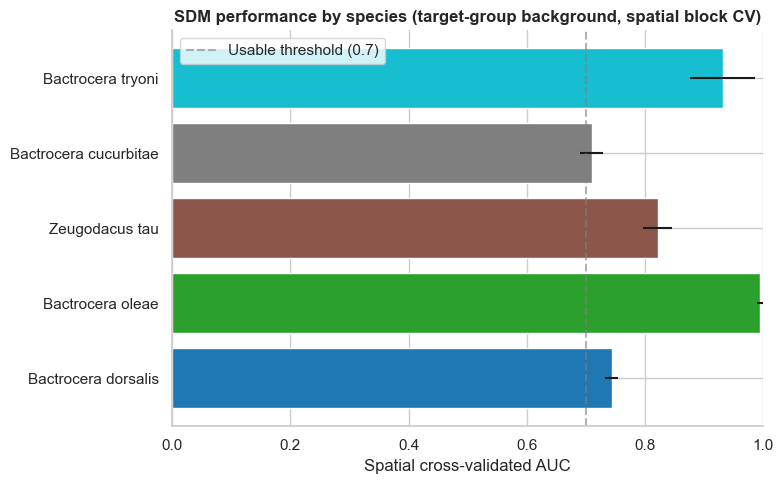

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
ax.barh(results_df['species'], results_df['auc'], xerr=results_df['auc_std'], color=colors)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.6, label='Usable threshold (0.7)')
ax.set_xlabel('Spatial cross-validated AUC')
ax.set_title('SDM performance by species (target-group background, spatial block CV)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/sdm_auc_by_species.png', dpi=150)
plt.show()

### Feature importance
A sanity check on what each model is actually using to make predictions.

In [19]:
importance_rows = []
for species, model in models.items():
    importances = pd.Series(model.feature_importances_, index=covariate_cols)
    top5 = importances.sort_values(ascending=False).head(5)
    for cov, val in top5.items():
        importance_rows.append({'species': species, 'covariate': cov, 'importance': val})

importance_df = pd.DataFrame(importance_rows)
importance_df.pivot(index='species', columns='covariate', values='importance').fillna(0)

covariate,bio_1,bio_10,bio_11,bio_12,bio_13,bio_15,bio_18,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9
species,,,,,,,,,,,,,,,
Bactrocera cucurbitae,0.099320,0.070886,0.058743,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071655,0.066998,0.000000,0.000000,0.000000
Bactrocera dorsalis,0.071206,0.000000,0.069286,0.000000,0.000000,0.000000,0.000000,0.070839,0.000000,0.000000,0.000000,0.139810,0.081433,0.000000,0.000000
Bactrocera oleae,0.100135,0.000000,0.098793,0.000000,0.117539,0.000000,0.142243,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.229602,0.000000
Bactrocera tryoni,0.000000,0.084271,0.000000,0.000000,0.000000,0.110184,0.000000,0.000000,0.142103,0.000000,0.000000,0.074015,0.000000,0.000000,0.073701
Zeugodacus tau,0.000000,0.000000,0.000000,0.059513,0.000000,0.000000,0.094197,0.000000,0.098674,0.056913,0.000000,0.000000,0.000000,0.000000,0.127016


## Part 4: Suitability Mapping with an Honesty Check

Before trusting a suitability prediction in a new region, we check whether that region's environmental conditions actually fall within the range the model was trained on. Where they do not, the model is extrapolating rather than interpolating, and any prediction there should be treated as a hypothesis, not a validated forecast. This matters specifically because East Africa and Africa at large has very few or, for some species, zero occurrence records in this dataset: *Bactrocera oleae*, *Zeugodacus tau*, and *Bactrocera tryoni* have no East African records at all, while *Bactrocera dorsalis* and *Bactrocera cucurbitae* have a small number (22 and 14 respectively). This does not necessarily mean these species are absent there; it more likely reflects lower citizen-science participation in the region. Established populations of *B. dorsalis* and *B. cucurbitae* are in fact documented in the pest management literature for East Africa. The novelty check below flags where a prediction is well supported by training data versus where it is a climate-based extrapolation.

In [40]:
#Novelty check function
def flag_novel_conditions(new_data, train_presence, covariate_cols, novelty_threshold=0.15):
    """
    Flags a location as climatically novel only if a meaningful fraction of covariates
    (default: more than 15%, i.e. more than 3 of 22) fall outside this species' own
    observed range, rather than flagging on any single covariate. A single-covariate
    rule was tried first and produced implausibly high novelty rates (59-96% of the
    entire continent) that contradicted the suitability maps themselves, because with
    22 covariates it takes only one to sit at a boundary for a location to be flagged,
    even when the other 21 are entirely typical for the species. Requiring multiple
    covariates to be simultaneously out of range is a more realistic test of whether a
    location's overall climate is genuinely unlike anything the species has been
    confirmed in.
    """
    novel_flags = pd.DataFrame(index=new_data.index)
    for col in covariate_cols:
        lo, hi = train_presence[col].min(), train_presence[col].max()
        novel_flags[col] = (new_data[col] < lo) | (new_data[col] > hi)

    result = new_data.copy()
    result['n_novel_covariates'] = novel_flags.sum(axis=1)
    result['is_novel'] = (result['n_novel_covariates'] / len(covariate_cols)) > novelty_threshold
    return result

In [41]:
def build_grid(lat_range, lon_range, step=0.5):
    lats = np.arange(lat_range[0], lat_range[1], step)
    lons = np.arange(lon_range[0], lon_range[1], step)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    return pd.DataFrame({'latitude': lat_grid.ravel(), 'longitude': lon_grid.ravel()})

AFRICA_LAT_RANGE = (-35, 38)
AFRICA_LON_RANGE = (-18, 52)

africa_grid = build_grid(AFRICA_LAT_RANGE, AFRICA_LON_RANGE, step=0.5)
africa_grid = extract_covariates(africa_grid)
africa_grid = africa_grid.dropna(subset=covariate_cols)
if africa_grid['ph'].max() > 14:
    africa_grid['ph'] = africa_grid['ph'] / 10
print('Africa grid points:', len(africa_grid))

Africa grid points: 11511


In [42]:
#predict and check novelty
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def plot_suitability_map(grid_df, title, lon_range, lat_range, presence_points=None, grid_res=300, smooth_sigma=3):
    grid_lon, grid_lat = np.meshgrid(
        np.linspace(lon_range[0], lon_range[1], grid_res),
        np.linspace(lat_range[0], lat_range[1], grid_res)
    )
    points = (grid_df['longitude'], grid_df['latitude'])
    grid_linear = griddata(points, grid_df['suitability'], (grid_lon, grid_lat), method='linear')
    grid_nearest = griddata(points, grid_df['suitability'], (grid_lon, grid_lat), method='nearest')
    grid_z = np.where(np.isnan(grid_linear), grid_nearest, grid_linear)
    grid_z_smooth = gaussian_filter(grid_z, sigma=smooth_sigma)

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', zorder=0)
    mesh = ax.contourf(grid_lon, grid_lat, grid_z_smooth, levels=15, cmap='YlOrRd',
                        alpha=0.85, transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='-', edgecolor='gray', zorder=3)

    if presence_points is not None and len(presence_points) > 0:
        ax.scatter(presence_points['longitude'], presence_points['latitude'],
                   s=25, facecolor='none', edgecolor='blue', linewidth=1.2,
                   transform=ccrs.PlateCarree(), zorder=5, label='Observed occurrences')
        ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.6, pad=0.05)
    cbar.set_label('Predicted climatic suitability', fontsize=11)

    ax.annotate('N', xy=(0.95, 0.92), xycoords='axes fraction', fontsize=14, fontweight='bold', ha='center')
    ax.annotate('', xy=(0.95, 0.90), xytext=(0.95, 0.82), xycoords='axes fraction',
                arrowprops=dict(facecolor='black', width=3, headwidth=10))

    center_lat = (lat_range[0] + lat_range[1]) / 2
    bar_km = 1000
    start_lon = lon_range[0] + (lon_range[1] - lon_range[0]) * 0.05
    end_lon = start_lon + (bar_km / 111.32 / np.cos(np.radians(center_lat)))
    bar_lat = lat_range[0] + (lat_range[1] - lat_range[0]) * 0.05
    ax.plot([start_lon, end_lon], [bar_lat, bar_lat], color='black', linewidth=3, transform=ccrs.PlateCarree(), zorder=4)
    ax.text((start_lon + end_lon) / 2, bar_lat + 1, f'{bar_km} km', ha='center', fontsize=9, transform=ccrs.PlateCarree())

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    return fig, ax

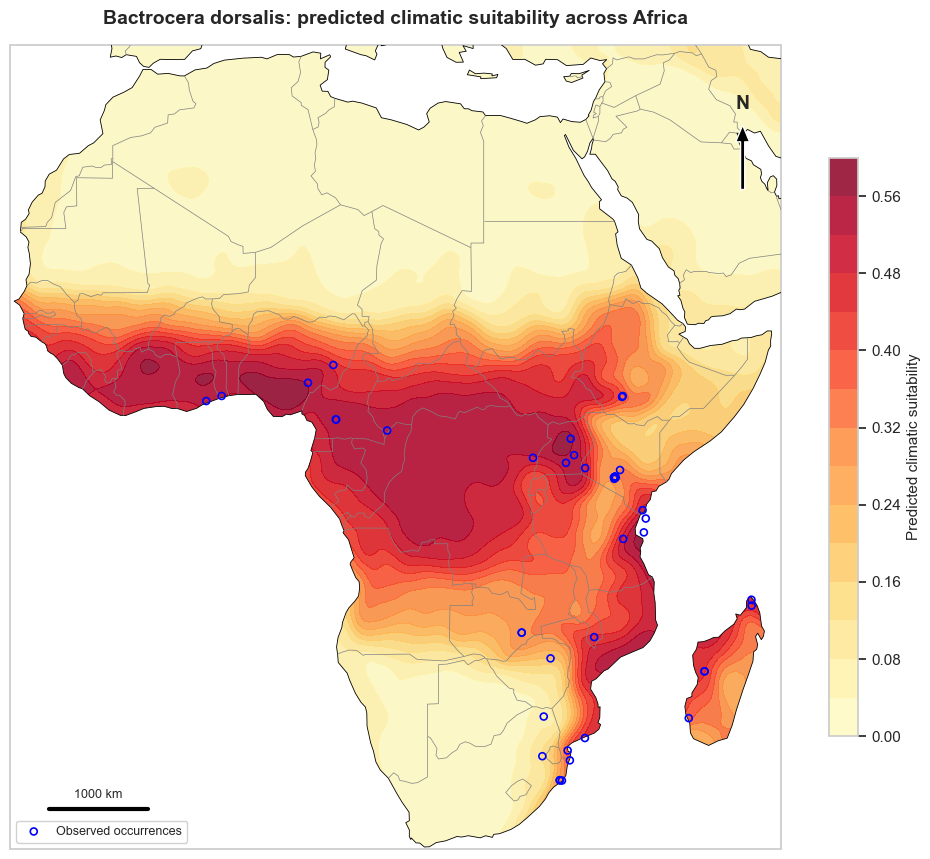

Bactrocera dorsalis: 41.0% of Africa grid cells are outside this species' own known climate range



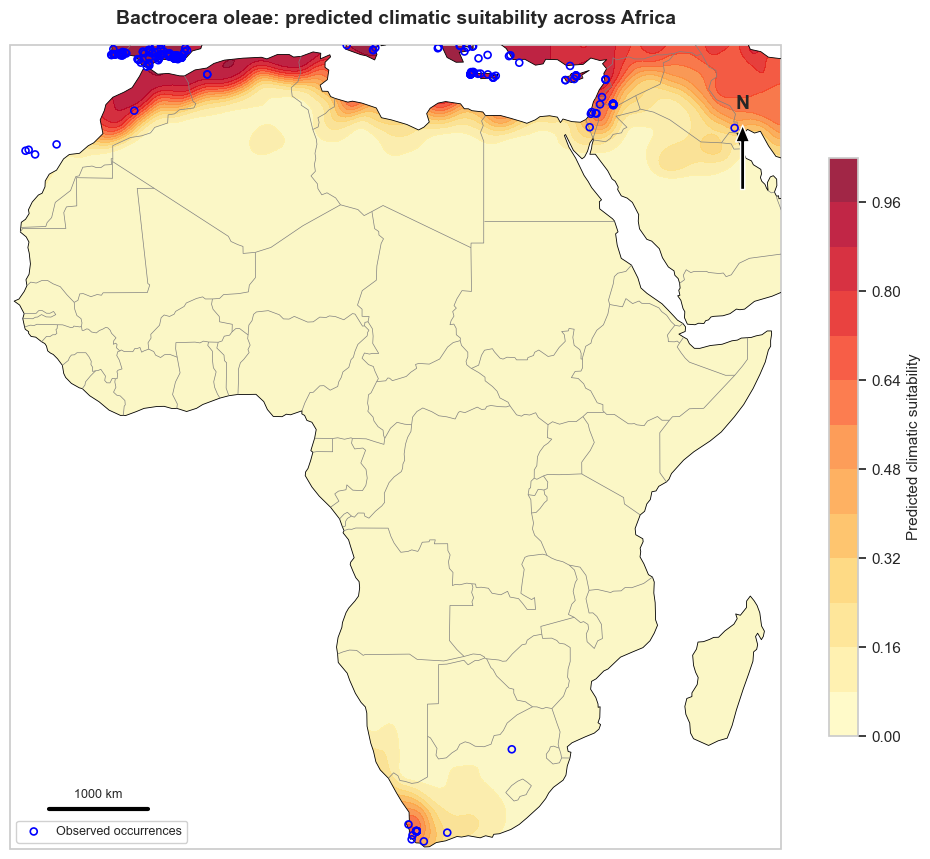

Bactrocera oleae: 82.5% of Africa grid cells are outside this species' own known climate range



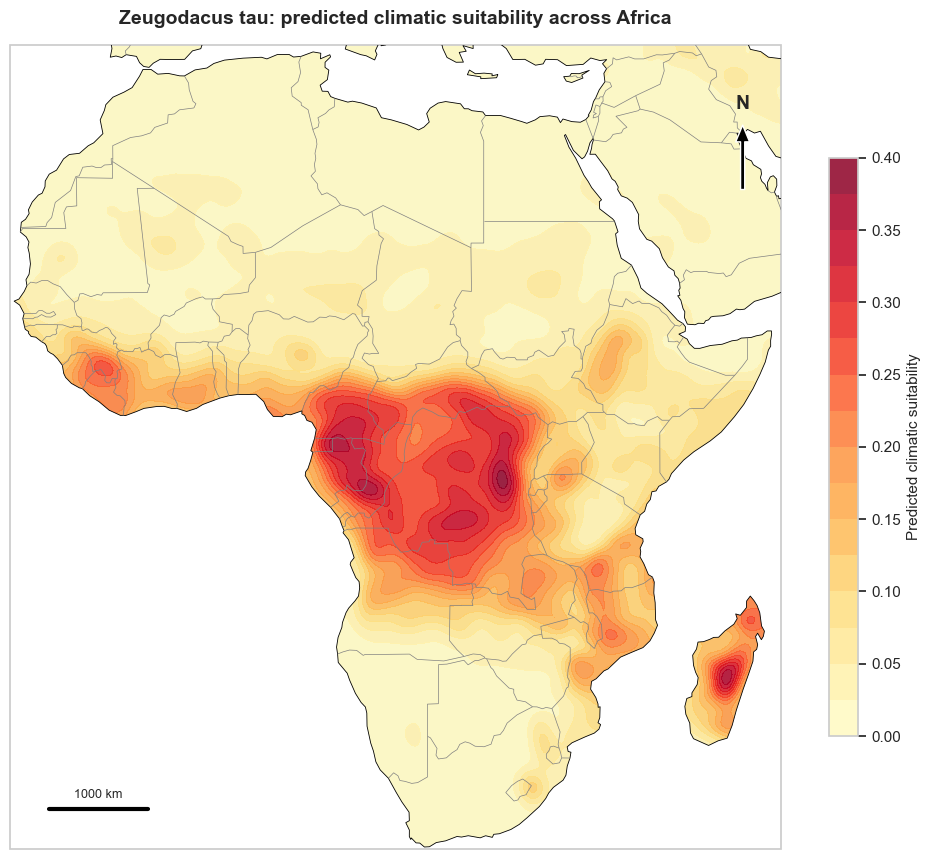

Zeugodacus tau: 48.7% of Africa grid cells are outside this species' own known climate range



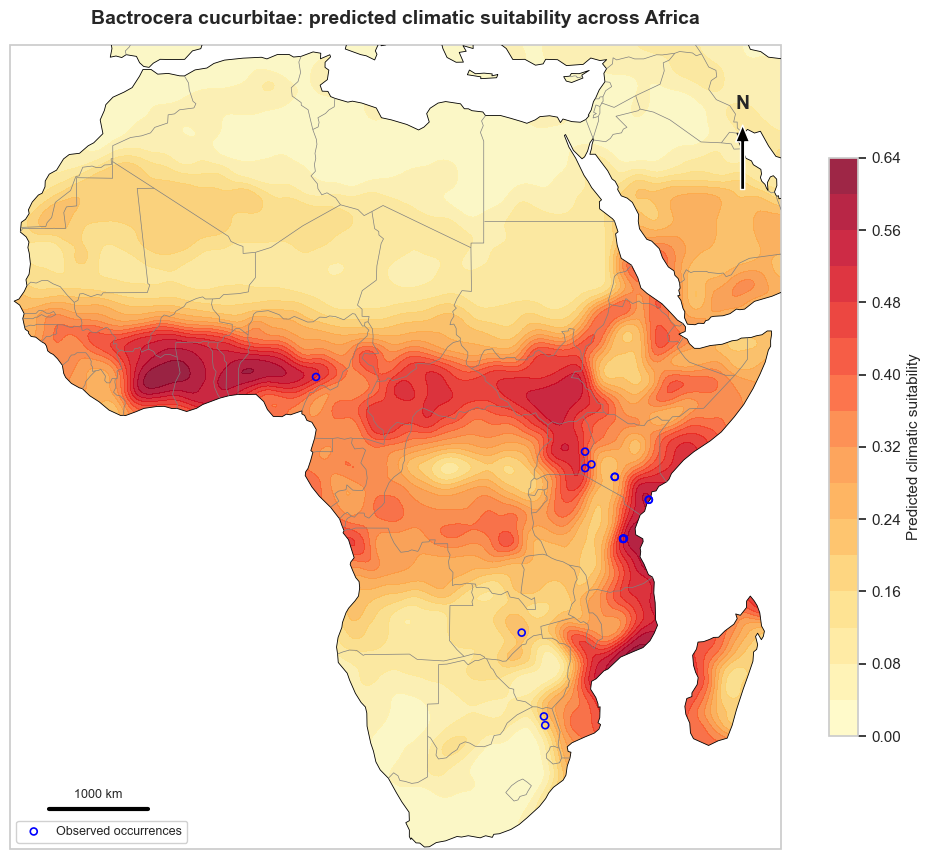

Bactrocera cucurbitae: 30.3% of Africa grid cells are outside this species' own known climate range



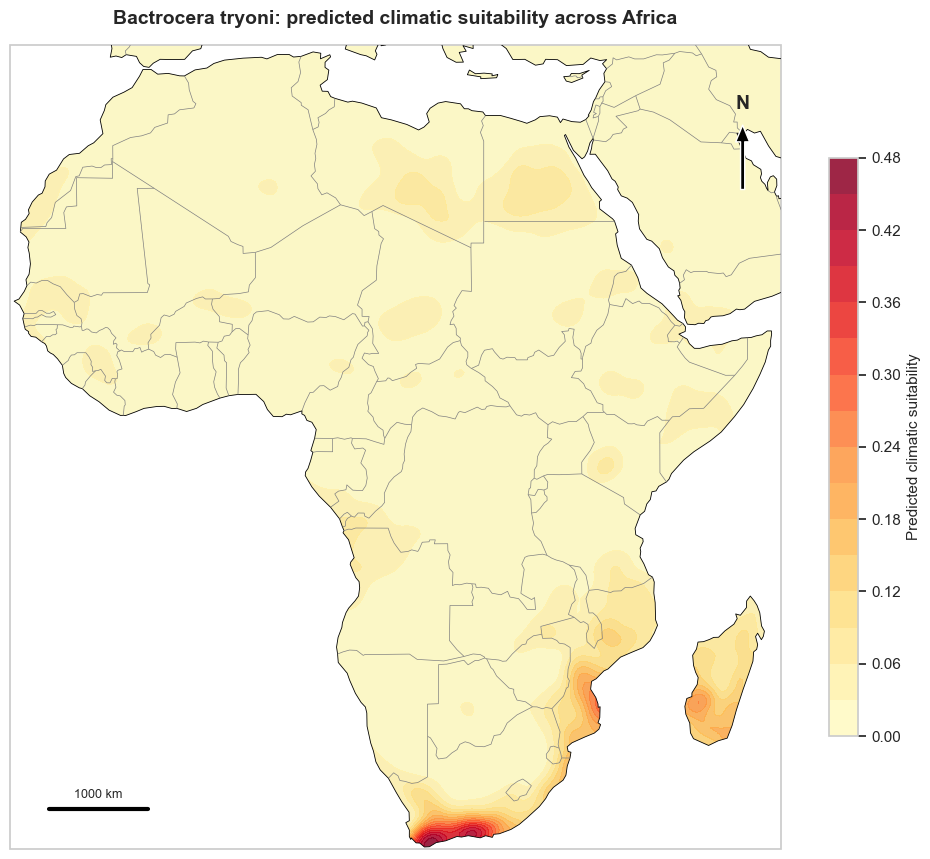

Bactrocera tryoni: 62.1% of Africa grid cells are outside this species' own known climate range



In [43]:
#Map it
for species in TARGET_SPECIES:
    presence_for_species = species_covariates[species_covariates['scientific_name'] == species]

    grid_checked = flag_novel_conditions(africa_grid, presence_for_species, covariate_cols)
    grid_checked['suitability'] = models[species].predict_proba(grid_checked[covariate_cols])[:, 1]

    occurrences_africa = presence_for_species[
        (presence_for_species['longitude'] >= AFRICA_LON_RANGE[0]) &
        (presence_for_species['longitude'] <= AFRICA_LON_RANGE[1]) &
        (presence_for_species['latitude'] >= AFRICA_LAT_RANGE[0]) &
        (presence_for_species['latitude'] <= AFRICA_LAT_RANGE[1])
    ]

    fig, ax = plot_suitability_map(
        grid_checked,
        title=f'{species}: predicted climatic suitability across Africa',
        lon_range=AFRICA_LON_RANGE, lat_range=AFRICA_LAT_RANGE,
        presence_points=occurrences_africa
    )
    safe_name = species.replace(' ', '_')
    plt.savefig(f'../outputs/figures/africa_suitability_{safe_name}.png', dpi=200, bbox_inches='tight')
    plt.show()

    novel_pct = grid_checked['is_novel'].mean() * 100
    print(f"{species}: {novel_pct:.1f}% of Africa grid cells are outside this species' own known climate range\n")

In [ ]:
%pip install cartopy scipy

Note: you may need to restart the kernel to use updated packages.


**Reading the above map**: the left panel shows predicted suitability everywhere in the East African bounding box. The right panel shows, separately, where that prediction is trustworthy (green, conditions similar to what the model was trained on) versus where it is an extrapolation into conditions the model never saw (red, treat as a hypothesis rather than a validated forecast). High suitability in a red zone should be reported cautiously.

## Part 5: Farmer-Facing Risk Lookup

This combines the climate suitability model (Part 3 and 4) with the host-plant association table (Part 1) into a single, practical output: given a location and a crop, which pest species are climatically likely to be present, and is this crop a documented host for them.

In [26]:
def assess_risk(lat, lon, crop, models, host_plant_lookup, covariate_cols, env_files):
    """
    Given a location and a crop the farmer grows, report which modeled fruit fly species
    are climatically likely to be present, and whether the crop is a documented host for
    each.
    """
    point = pd.DataFrame({'latitude': [lat], 'longitude': [lon]})
    point = extract_covariates(point, fill_gaps=True)

    if point[covariate_cols].isna().any(axis=1).iloc[0]:
        return {'error': 'No environmental data available at this location'}

    if point['ph'].iloc[0] > 14:
        point['ph'] = point['ph'] / 10

    findings = []
    for species, model in models.items():
        suitability = model.predict_proba(point[covariate_cols])[:, 1][0]
        hosts = host_plant_lookup.get(species, [])
        is_host = any(crop.lower() in h.lower() or h.lower() in crop.lower() for h in hosts)
        findings.append({
            'species': species,
            'climatic_suitability': round(float(suitability), 3),
            'documented_hosts': hosts,
            'crop_is_documented_host': is_host,
        })

    findings = sorted(findings, key=lambda r: r['climatic_suitability'], reverse=True)
    return {'location': (lat, lon), 'crop_queried': crop, 'species_assessment': findings}

In [27]:
def suitability_band(score):
    if score >= 0.6:
        return 'HIGH'
    elif score >= 0.4:
        return 'MODERATE'
    else:
        return 'LOW'

result = assess_risk(
    lat=-1.286389, lon=36.817223, crop='Mangifera indica',
    models=models, host_plant_lookup=host_plant_lookup,
    covariate_cols=covariate_cols, env_files=env_files
)

for row in result['species_assessment']:
    band = suitability_band(row['climatic_suitability'])
    host_note = 'documented host' if row['crop_is_documented_host'] else 'not a documented host'
    print(f"{row['species']}: suitability={row['climatic_suitability']} ({band}), {host_note}")

Bactrocera dorsalis: suitability=0.48 (MODERATE), documented host
Bactrocera cucurbitae: suitability=0.151 (LOW), not a documented host
Zeugodacus tau: suitability=0.069 (LOW), not a documented host
Bactrocera tryoni: suitability=0.019 (LOW), documented host
Bactrocera oleae: suitability=0.0 (LOW), not a documented host


## Analysis Summary

**Host-pest interaction analysis**: 1,673 interaction study records covered 32 fly species and
12 host plants. Associations closely matched known literature: *Bactrocera oleae* associated
almost exclusively with *Olea europaea* (olive, 730 of 738 records), and *Bactrocera cucurbitae*
almost exclusively with Cucurbitaceae (622 of 626 records), consistent with known host
specificity for these species.

**Species Distribution Models**: five species had sufficient occurrence data to model
(*Bactrocera dorsalis*, *Bactrocera oleae*, *Zeugodacus tau*, *Bactrocera cucurbitae*,
*Bactrocera tryoni*). Using target-group background sampling and spatial block cross-validation,
AUC ranged from 0.71 (*B. cucurbitae*) to 0.99 (*B. oleae*):

| Species | n presence | AUC |
|---|---|---|
| Bactrocera oleae | 481 | 0.995 |
| Bactrocera tryoni | 244 | 0.931 |
| Zeugodacus tau | 435 | 0.821 |
| Bactrocera dorsalis | 1499 | 0.744 |
| Bactrocera cucurbitae | 428 | 0.710 |

Performance correlated with known ecological specialization: climate specialists scored
highest, broad generalists scored lower but still usable. Feature importance was distinct per
species and ecologically coherent, for example *B. oleae* was driven by mean temperature of
the wettest quarter and precipitation of the warmest quarter, consistent with a Mediterranean
wet-winter, dry-summer climate signature, while *B. tryoni* was driven by isothermality, a
known important variable in Australian biogeography.

**Africa suitability mapping and honesty check**: East African occurrence records are sparse
to nonexistent for the modeled species (*B. dorsalis*: 22, *B. cucurbitae*: 14, the remaining
three: 0), reflecting lower regional citizen science participation rather than true absence.
A species-specific novelty check (fraction of Africa outside each species' own confirmed
climate range) ranged from 30 percent (*B. cucurbitae*) to 83 percent (*B. oleae*), independently
reproducing the same specialist-versus-generalist pattern seen in the AUC results.
*B. oleae*'s suitability map correctly restricts high suitability to the Mediterranean coastal
fringe and shows near-zero suitability across sub-Saharan Africa, providing strong evidence
the models learned genuine climate signal rather than incidental correlation.

**Farmer-facing risk lookup**: combining climate suitability with the host-plant lookup table
produces an actionable output without needing independent host-plant location data. For
example, a query for Nairobi, Kenya growing mango correctly flags *Bactrocera dorsalis* as
the primary concern (MODERATE suitability, documented host), consistent with its
literature-documented established status as an East African mango pest.

**Limitations**: host-plant location data in this dataset is confounded with fly presence
(recorded at the same coordinates), so it cannot serve as an independent spatial layer; the
farmer-facing tool instead relies on the farmer's own knowledge of what they grow. Predictions
for regions with sparse or no occurrence data (particularly East Africa for three of five
species) should be treated as hypotheses grounded in climate similarity, not validated
forecasts, per the novelty check above.

These findings, together with the trained models and host-plant lookup table saved in
`outputs/models/`, feed into `notebooks/03_ensemble_modeling.ipynb`, which extends this
pipeline with multicollinearity-reduced covariates and a multi-classifier ensemble.

In [45]:
# Save all species' Africa grid predictions for dashboard use (avoids needing raster files at deployment)
all_predictions = []
for species in TARGET_SPECIES:
    presence_for_species = species_covariates[species_covariates['scientific_name'] == species]
    grid_checked = flag_novel_conditions(africa_grid, presence_for_species, covariate_cols)
    grid_checked['suitability'] = models[species].predict_proba(grid_checked[covariate_cols])[:, 1]
    grid_checked['species'] = species
    all_predictions.append(grid_checked[['latitude', 'longitude', 'species', 'suitability', 'is_novel']])

africa_predictions_primary = pd.concat(all_predictions, ignore_index=True)
africa_predictions_primary.to_csv('../outputs/models/africa_grid_predictions_primary.csv', index=False)
print('Saved:', africa_predictions_primary.shape)

Saved: (57555, 5)
